In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


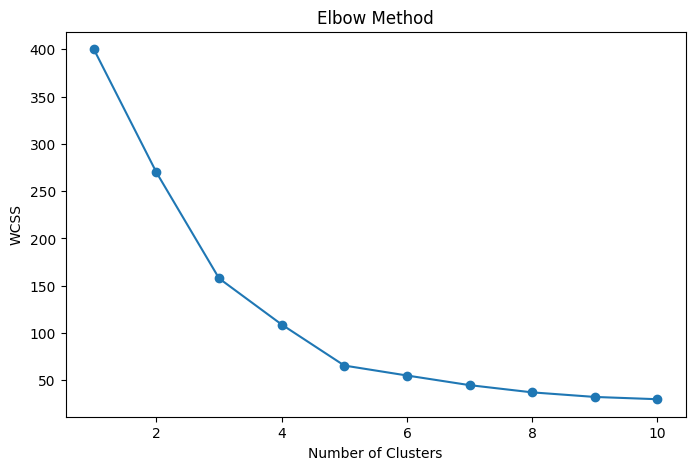

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()



In [11]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


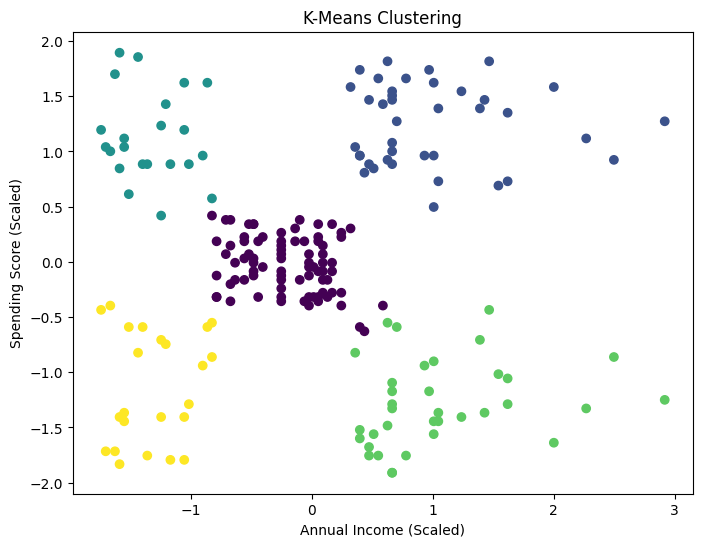

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.title("K-Means Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.show()

In [13]:
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", silhouette_kmeans)

K-Means Silhouette Score: 0.5546571631111091


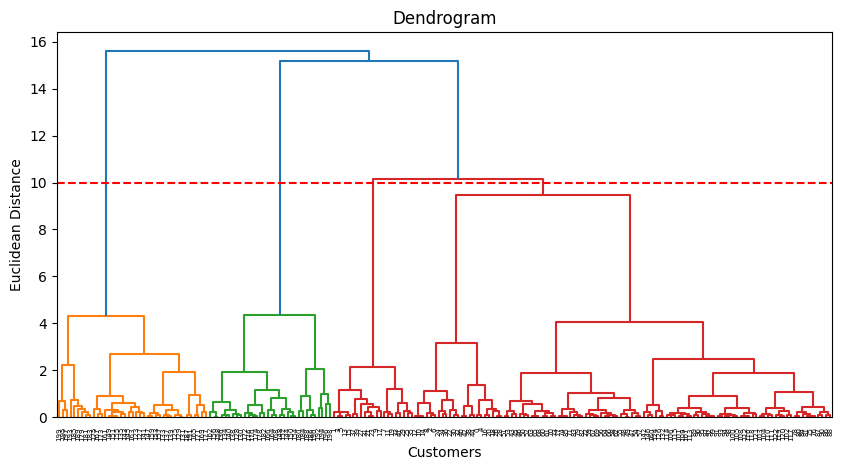

In [14]:
plt.figure(figsize=(10,5))

dendrogram(linkage(X_scaled, method='ward'))
plt.axhline(y=10, color='red',linestyle='--')
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [15]:
hc = AgglomerativeClustering(n_clusters=5)

hc_labels = hc.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hc_labels

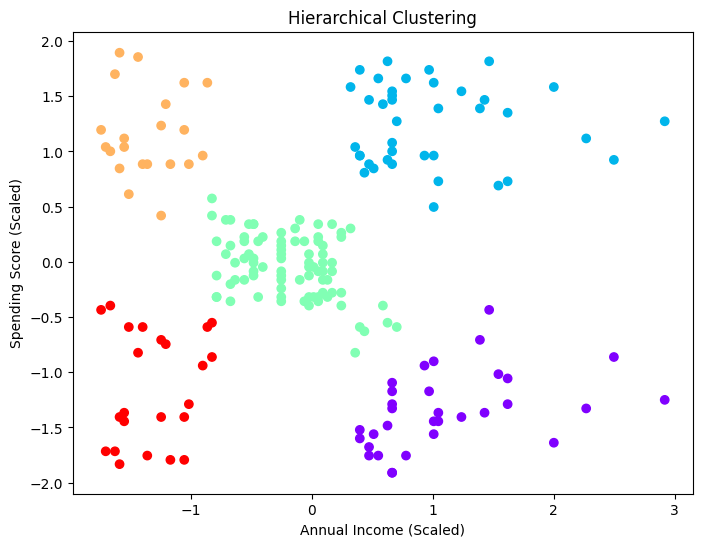

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=hc_labels,
    cmap='rainbow'
)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.show()

In [17]:
silhouette_hc = silhouette_score(X_scaled, hc_labels)
db_hc = davies_bouldin_score(X_scaled, hc_labels)

print("Hierarchical Silhouette Score:", silhouette_hc)
print("Hierarchical Davies-Bouldin Index:", db_hc)

Hierarchical Silhouette Score: 0.5538089226688662
Hierarchical Davies-Bouldin Index: 0.5778621190740154


In [18]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

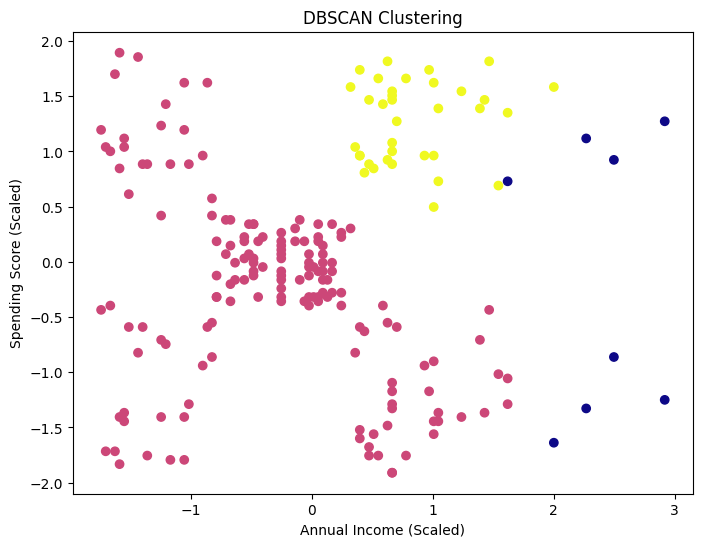

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=dbscan_labels,
    cmap='plasma'
)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.show()

In [20]:
if len(set(dbscan_labels)) > 1:
    silhouette_dbscan = silhouette_score(X_scaled, dbscan_labels)
    db_dbscan = davies_bouldin_score(X_scaled, dbscan_labels)

    print("DBSCAN Silhouette Score:", silhouette_dbscan)
    print("DBSCAN Davies-Bouldin Index:", db_dbscan)
else:
    print("DBSCAN found only one cluster.")

DBSCAN Silhouette Score: 0.35044619989666004
DBSCAN Davies-Bouldin Index: 0.8285103931757107


In [22]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN"
    ],
    "Silhouette Score": [
        silhouette_kmeans,
        silhouette_hc,
        silhouette_dbscan
    ],
    "Davies-Bouldin Index": [
        davies_bouldin_score(X_scaled, kmeans_labels),
        db_hc,
        db_dbscan
    ]
})

comparison

,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.554657,0.572236
1,Hierarchical Clustering,0.553809,0.577862
2,DBSCAN,0.350446,0.828510
